In [ ]:
import sys

sys.path.append('..')

import matplotlib.pyplot as plt
from torchvision import transforms
import numpy as np

from virtuesm2.models.virtuesm2_hf import VirTuesM2_HF
from virtuesm2.utils.utils import load_marker_embedding_dict, load_marker_embeddings
from virtuesm2.virtual_staining.virtuesm2_vstaining_hf import VM2_VirtualStaining_HF
from scipy.stats import pearsonr

from spora_io import ComposedImagingDataset

# if jupyter cannot read the spora datasets dir from your environment, you can set it here:
# import os
# os.environ["SPORA_DATASETS_DIR"] = "..."

/mnt/aimm/scratch/querfurth/code/virtues-world/virtues-m2/virtuesm2/models/layers/swiglu_ffn.py:38: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/mnt/aimm/scratch/querfurth/code/virtues-world/virtues-m2/virtuesm2/models/layers/attention_qkv_separate.py:17: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
2026-09-07 15:05:02.743 | INFO     | virtuesm2.models.layers:<module>:22 - Using xformers version 0.0.29.post3 for attention layers.


### VirTual Staining example

This notebook demonstrates how we can infer new markers from the H&E input. For this, we first load the frozen VirTues-M2 model, construct the VirTues-inspired decoder and attach it to the outputs of VirTues-M2.

Using the encoded H&E image, we condition our virtual staining decoder using masking tokens to which the corresponding esm embedding of the marker of interest is added. We repeat this process for every marker.

#### Load the multiplex and H&E sample crop

In [ ]:
undo_he_norm = transforms.Compose([
    transforms.Normalize(mean=[0., 0., 0.], std=[1/0.195, 1/0.2316, 1/0.1816]),
    transforms.Normalize(mean=[-0.7068, -0.5755, -0.722], std=[1., 1., 1.]),
])

ds = ComposedImagingDataset(
    name="hickey2023organization",
    modalities=["he", "codex"],
    tile_size=224,
    resolution=1.0,
    modality_kwargs={
        "codex":   {"standardization": "quantile_clipping/uq_0.99_image", "use_mean_std": False, "filter_list": ["gaussian_blur"], "replace_nuclear_uniprot_ids": True},
        "cycif":   {"standardization": "quantile_clipping/uq_0.99_image", "use_mean_std": False, "filter_list": ["gaussian_blur"], "replace_nuclear_uniprot_ids": True},
        "he"   :   {"mean_std_type"  : "hibou"},
    },

)

tissue_id = "hickey2023organization_tgznyajr_0004" # coords of example crop: (2400, 800)
sample_mx = ds.get_dataset("codex").get_tile_by_coordinates(tissue_id, row=2400, col=800)
sample_he = ds.get_dataset("he").get_tile_by_coordinates(tissue_id, row=2400, col=800)

2026-09-07 15:05:03.485 | INFO     | spora_io.utils.utils:print_verbose:26 - Initializing modality 'he'...
2026-09-07 15:05:03.486 | WARNING  | spora_io.utils.utils:print_verbose:28 - No tile strategy provided, using default.
2026-09-07 15:05:03.523 | INFO     | spora_io.utils.utils:print_verbose:26 - Loaded tile coordinates from /mnt/aimm/scratch/datasets_v2/hickey2023organization/tiling/1_0mpp/default/224_tile_coordinates.parquet
2026-09-07 15:05:03.523 | DEBUG    | spora_io.utils.utils:print_verbose:32 - Dataset hickey2023organization has 11536 tiles of size 224 at resolution 1_0mpp.
2026-09-07 15:05:03.523 | INFO     | spora_io.utils.utils:print_verbose:26 - Initializing modality 'codex'...
2026-09-07 15:05:03.524 | WARNING  | spora_io.utils.utils:print_verbose:28 - No tile strategy provided, using default.
2026-09-07 15:05:03.530 | INFO     | spora_io.utils.utils:print_verbose:26 - Replaced UniProt IDs for 2 nuclear channels with P68431.
2026-09-07 15:05:03.539 | INFO     | spora_

Filters to apply: ['gaussian_blur']


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

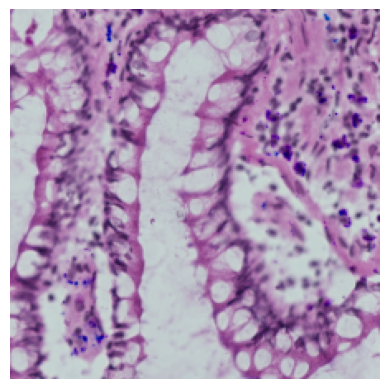

In [3]:
mx_image = sample_mx.image
he_image = sample_he.image
marker_names = sample_mx.channel_names
uniprot_ids = sample_mx.uniprot_ids

# Drop DRAQ5 from the list of uniprot_ids and corresponding embeddings
mx_image = mx_image[marker_names != "DRAQ5", :, :]
uniprot_ids = uniprot_ids[marker_names != "DRAQ5"]
marker_names = marker_names[marker_names != "DRAQ5"]

he_image_raw = undo_he_norm(he_image).permute(1, 2, 0).numpy()
he_image_raw = np.clip(he_image_raw, 0, 1)
plt.imshow(he_image_raw)
plt.axis("off")


#### Load ESM-2 embeddings

In [4]:
esm_embedding_dict = load_marker_embedding_dict("../example_data/esm_embeddings")
esm_embeddings = load_marker_embeddings("../example_data/esm_embeddings")

In [ ]:
target_uniprot_ids = ['P68431', 'Q04695', 'P16284', 'P46013', 'P08575', 'P34810', 'Q86VB7', 'P07766', 'P01730', 'P01732', 'P08575-4']
uniprot_ids_filter = [uid in target_uniprot_ids for uid in uniprot_ids]

mx_image = mx_image[uniprot_ids_filter, :, :]
marker_names = marker_names[uniprot_ids_filter]
uniprot_ids = uniprot_ids[uniprot_ids_filter]

#### Apply Normalization

In [6]:
mean_he = [0.7068, 0.5755, 0.722]
std_he = [0.195, 0.2316, 0.1816]
he_normalization = transforms.Normalize(mean=mean_he, std=std_he)

#### Create Model

In [7]:
vm2_encoder = VirTuesM2_HF.from_pretrained("bunnelab/virtues-m2", marker_embedding_dir="../example_data/esm_embeddings", revision="v2")

vstaining_model = VM2_VirtualStaining_HF.from_pretrained(
            "bunnelab/virtues-m2",
            vm2_encoder=vm2_encoder,
            marker_embedding_dir="../example_data/esm_embeddings",
            mode = "he",
            revision="v2",
        )
vstaining_model.eval()
vstaining_model.cuda()

VM2_VirtualStaining_HF(
  (model): VirTuesM2_HF(
    (he_embed_layer): PatchEmbed(
      (proj): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14))
      (norm): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
    )
    (mx_embed_layer): MultiplexTokenizer(
      (protein_encoder): Linear(in_features=640, out_features=1024, bias=True)
      (multiplex_patch_encoder): Linear(in_features=196, out_features=1024, bias=True)
      (layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (encoder): ModuleList(
        (0): MarkerAttentionEncoderBlock(
          (encoder_layer): TransformerEncoder(
            (layers): ModuleList(
              (0-1): 2 x TransformerEncoderBlock(
                (multi_head_attention): MHAwithPosEmb(
                  (W_q): Linear(in_features=1024, out_features=1024, bias=True)
                  (W_k): Linear(in_features=1024, out_features=1024, bias=True)
                  (W_v): Linear(in_features=1024, out_features=1024, bias

#### Encode the H&E + Virtually stain it

In [8]:
output = vstaining_model.forward([{
    "mx": None,
    "he": he_image,
    "target_uniprot_ids": target_uniprot_ids
}])

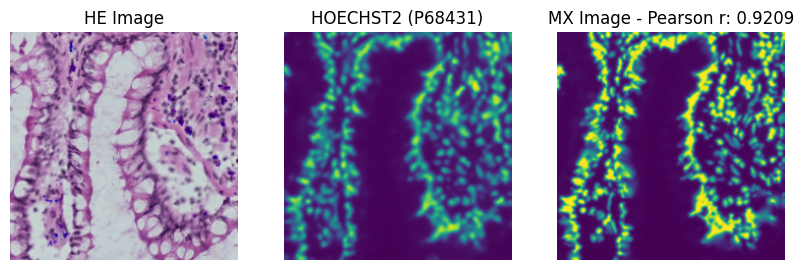

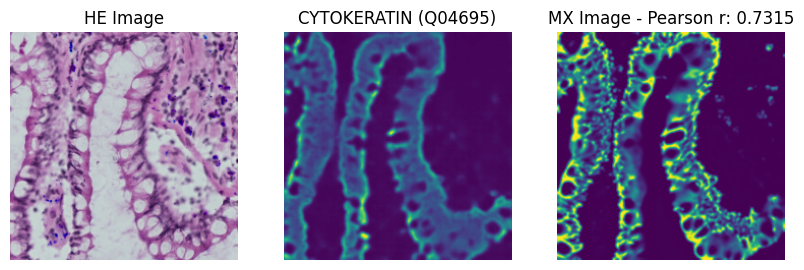

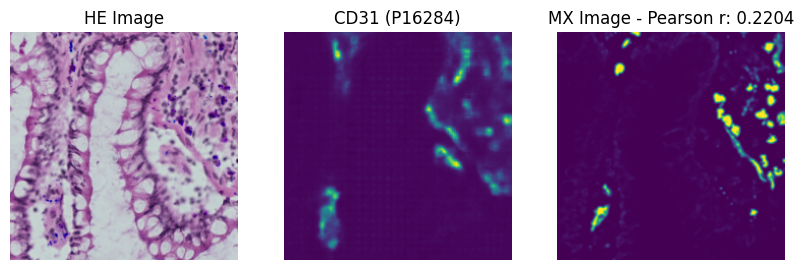

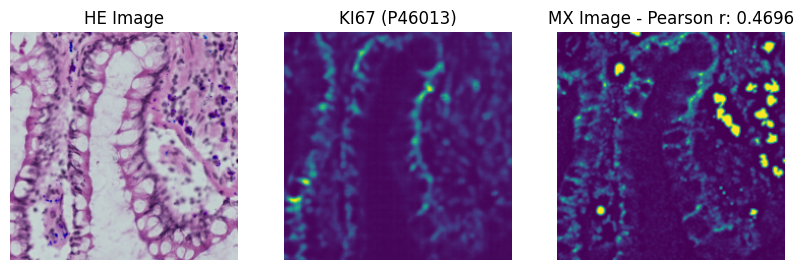

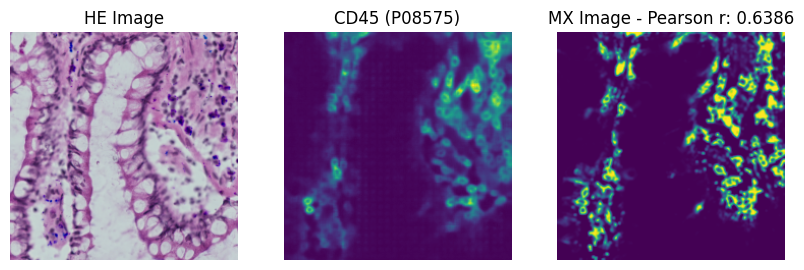

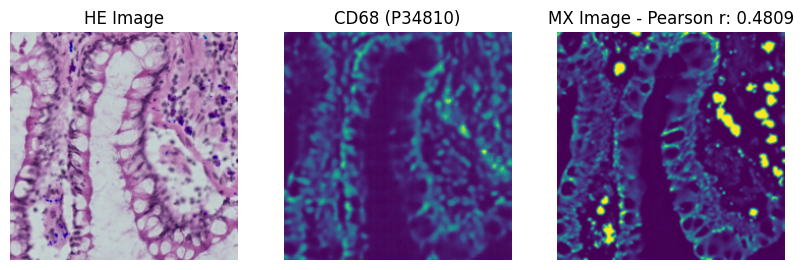

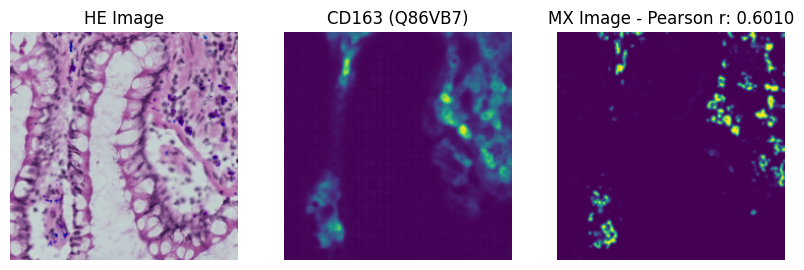

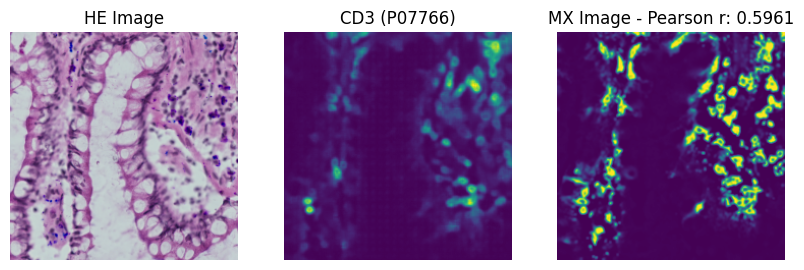

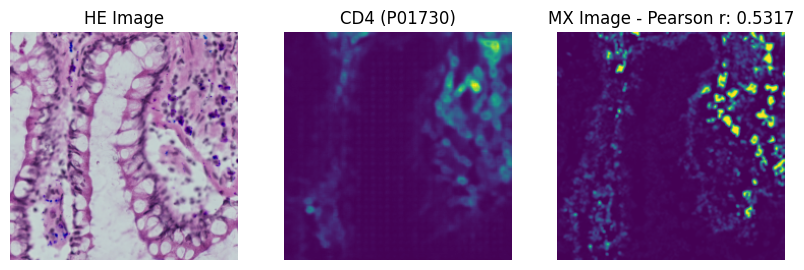

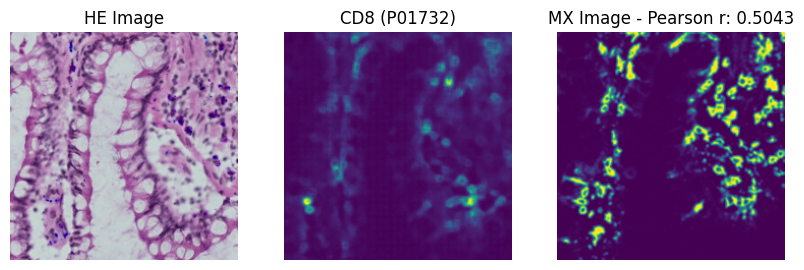

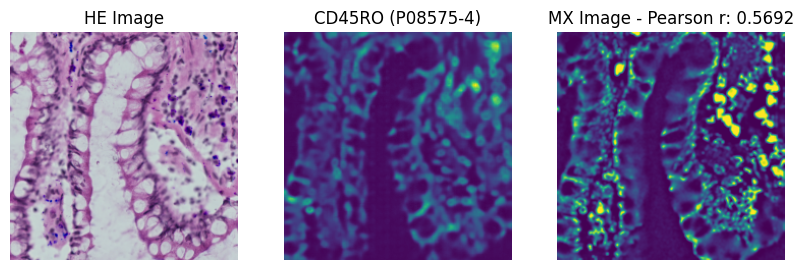

In [9]:
# show virtual stains and pearson correlation with mx images
virtual_stain = output[0].cpu().numpy()

for i in range(len(target_uniprot_ids)):
    fig, axs = plt.subplots(1,3, figsize=(10, 10))
    ch_idx_mx = list(uniprot_ids).index(target_uniprot_ids[i])
    axs[0].imshow(he_image_raw)
    axs[0].set_title("HE Image")
    axs[0].axis("off")
    axs[1].imshow(virtual_stain[i])
    axs[1].set_title(marker_names[ch_idx_mx] + f" ({target_uniprot_ids[i]})")
    axs[1].axis("off")
    axs[2].imshow(mx_image[ch_idx_mx])
    axs[2].axis("off")
    axs[2].set_title(f"MX Image - Pearson r: {pearsonr(virtual_stain[i].flatten(), mx_image[ch_idx_mx].cpu().numpy().flatten())[0]:.4f}")
    plt.show()